In [1]:
import time
import os
import cv2
import numpy as np
from imutils import paths
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms

# Key parameters
IMAGE_DIMS = (224, 224)  # ResNet18 expects 224x224 images
dataset_dir = "C:/Users/Souma Chakraborty/OneDrive/Desktop/ML_RESEARCH/Fruit And Vegetable Diseases Dataset"
ALLOWED_CLASSES = {"Banana__Healthy", "Banana__Rotten"}

class FruitDataset(Dataset):
    def __init__(self, imagePaths, labels, transform=None):
        self.imagePaths = imagePaths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.imagePaths)

    def __getitem__(self, idx):
        imagePath = self.imagePaths[idx]
        image = cv2.imread(imagePath)
        if image is None:
            raise ValueError(f"Failed to load image: {imagePath}")
        image = cv2.resize(image, IMAGE_DIMS)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        image = image.astype("float32") / 255.0
        if self.transform:
            image = self.transform(image)
        else:
            # Convert from HWC to CHW tensor
            image = torch.from_numpy(image.transpose(2, 0, 1))
        label = self.labels[idx]
        return image, label

def load_data():
    data = []
    labels = []
    imagePaths = list(paths.list_images(dataset_dir))
    print(f"Found {len(imagePaths)} images in total.")
    for imagePath in imagePaths:
        label = imagePath.split(os.path.sep)[-2]
        if label not in ALLOWED_CLASSES:
            continue
        if cv2.imread(imagePath) is None:
            print(f"Failed to load image: {imagePath}")
            continue
        data.append(imagePath)
        labels.append(label)
    print(f"\nProcessed {len(data)} images")
    print(f"Unique labels found: {set(labels)}")
    if len(data) == 0:
        raise ValueError("No images were processed. Check your dataset directory and paths.")
    le = LabelEncoder()
    encoded_labels = le.fit_transform(labels)
    (trainPaths, testPaths, trainLabels, testLabels) = train_test_split(
        data, encoded_labels, test_size=0.20, random_state=42)
    return trainPaths, testPaths, trainLabels, testLabels, le

trainPaths, testPaths, trainLabels, testLabels, le = load_data()

# Optional: additional transforms (if needed)
transform = transforms.Compose([
    transforms.ToTensor()  # Converts image from HWC [0,1] to CHW tensor [0,1]
])

# Create Dataset objects
trainDataset = FruitDataset(trainPaths, trainLabels, transform=None)
testDataset = FruitDataset(testPaths, testLabels, transform=None)

BS = 32  # Batch size
trainLoader = DataLoader(trainDataset, batch_size=BS, shuffle=True, num_workers=0, drop_last=True)
testLoader = DataLoader(testDataset, batch_size=BS, shuffle=False, num_workers=0, drop_last=True)


Found 14770 images in total.

Processed 4795 images
Unique labels found: {'Banana__Rotten', 'Banana__Healthy'}


In [2]:
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm
import torchvision.models as models
import time

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load pre-trained ResNet18 and modify the final fully connected layer for 2 classes
resnet18 = models.resnet18(pretrained=True)
num_features = resnet18.fc.in_features
resnet18.fc = nn.Linear(num_features, len(le.classes_))
resnet18 = resnet18.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(resnet18.parameters(), lr=1e-4)

print(resnet18)
print(f"Training ResNet18 on device: {device}")

EPOCHS = 5
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

print("[INFO] Training ResNet18 model...")
for epoch in range(EPOCHS):
    resnet18.train()
    running_loss = 0.0
    running_corrects = 0
    total = 0
    for images, labels in tqdm(trainLoader, desc=f"Epoch {epoch+1}/{EPOCHS}"):
        images = images.to(device)
        labels = labels.to(device)
        optimizer.zero_grad()
        outputs = resnet18(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        running_corrects += torch.sum(preds == labels.data)
        total += images.size(0)
    epoch_loss = running_loss / total
    epoch_acc = running_corrects.double() / total
    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_acc.item())
    
    resnet18.eval()
    val_running_loss = 0.0
    val_running_corrects = 0
    val_total = 0
    with torch.no_grad():
        for images, labels in testLoader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = resnet18(images)
            loss = criterion(outputs, labels)
            val_running_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            val_running_corrects += torch.sum(preds == labels.data)
            val_total += images.size(0)
    val_loss = val_running_loss / val_total
    val_acc = val_running_corrects.double() / val_total
    val_losses.append(val_loss)
    val_accuracies.append(val_acc.item())
    print(f"Epoch {epoch+1}/{EPOCHS}: Train loss {epoch_loss:.4f}, Train acc {epoch_acc:.4f}, Val loss {val_loss:.4f}, Val acc {val_acc:.4f}")

# Evaluation function
def evaluate(model, dataloader, device_eval):
    model.to(device_eval)
    model.eval()
    all_preds = []
    all_labels = []
    total_time = 0.0
    total_samples = 0
    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device_eval)
            start = time.time()
            outputs = model(images)
            end = time.time()
            total_time += (end - start)
            total_samples += images.size(0)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    accuracy = np.mean(np.array(all_preds) == np.array(all_labels))
    avg_inference_time = (total_time / total_samples) * 1000  # ms per image
    return accuracy, avg_inference_time, all_preds, all_labels

fp32_accuracy, fp32_inference_time, all_preds, all_labels = evaluate(resnet18, testLoader, device)
print(f"ResNet18 FP32 - Accuracy: {fp32_accuracy:.4f}, Inference Time: {fp32_inference_time:.2f} ms/image")


c:\Users\Souma Chakraborty\OneDrive\Desktop\ML_RESEARCH\resenv\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\Souma Chakraborty\OneDrive\Desktop\ML_RESEARCH\resenv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

Epoch 1/5: 100%|██████████| 119/119 [03:36<00:00,  1.82s/it]


Epoch 1/5: Train loss 0.0389, Train acc 0.9861, Val loss 0.0015, Val acc 1.0000


Epoch 2/5: 100%|██████████| 119/119 [03:48<00:00,  1.92s/it]


...

Epoch 3/5: Train loss 0.0027, Train acc 0.9997, Val loss 0.0017, Val acc 1.0000


Epoch 4/5: 100%|██████████| 119/119 [03:36<00:00,  1.82s/it]


Epoch 4/5: Train loss 0.0009, Train acc 1.0000, Val loss 0.0003, Val acc 1.0000


Epoch 5/5: 100%|██████████| 119/119 [03:30<00:00,  1.77s/it]


Epoch 5/5: Train loss 0.0138, Train acc 0.9958, Val loss 0.0015, Val acc 1.0000
ResNet18 FP32 - Accuracy: 1.0000, Inference Time: 16.38 ms/image


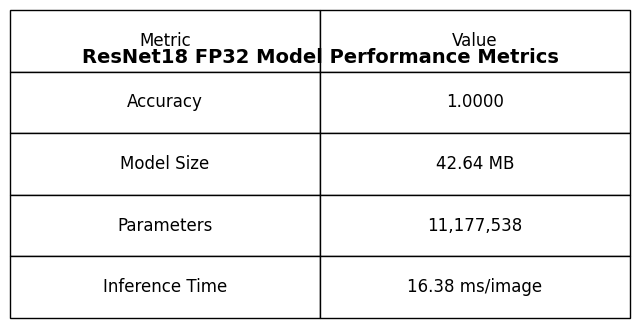

ResNet18 FP32 Model Classification Report:
              precision    recall  f1-score   support

     healthy       1.00      1.00      1.00       392
      rotten       1.00      1.00      1.00       536

    accuracy                           1.00       928
   macro avg       1.00      1.00      1.00       928
weighted avg       1.00      1.00      1.00       928



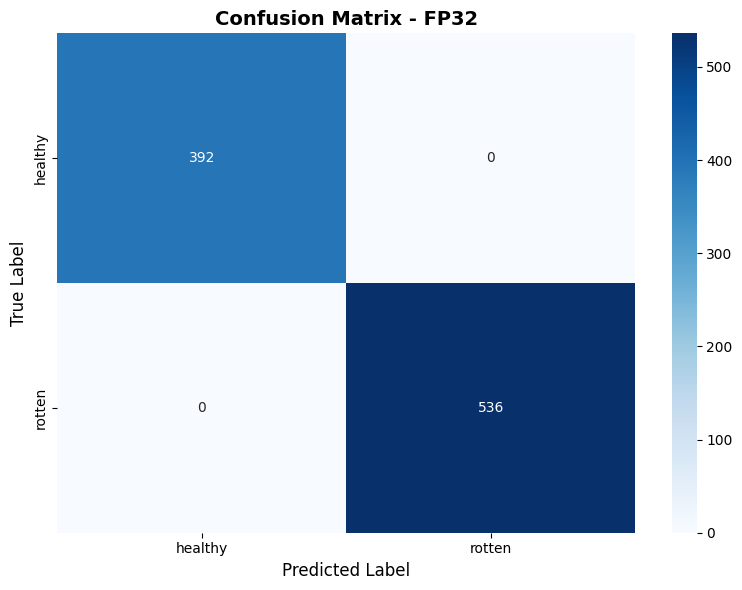

ResNet18 FP32 Model Confusion Matrix Accuracy: 1.0000
[INFO] Generating training history plot...


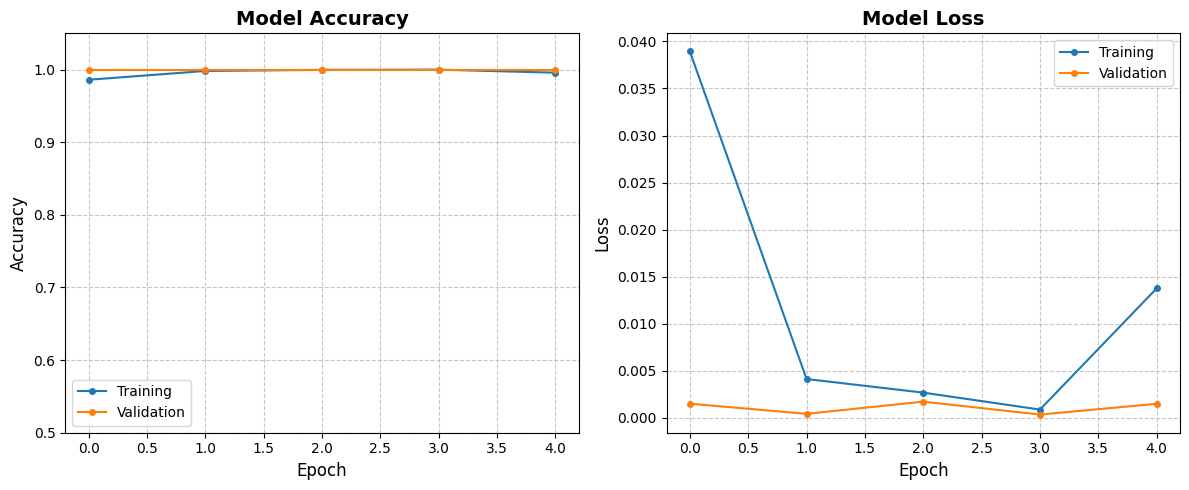

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

# -------------------------------
# Performance Metrics for FP32 ResNet18
# -------------------------------

# Create performance metrics table for FP32 model
def create_model_performance_metrics_fp32(model, test_accuracy, inference_time):
    total_params = sum(p.numel() for p in model.parameters())
    model_size_mb = total_params * 4 / (1024 * 1024)  # 4 bytes per parameter
    metrics = {
        'Metric': ['Accuracy', 'Model Size', 'Parameters', 'Inference Time'],
        'Value': [f'{test_accuracy:.4f}', f'{model_size_mb:.2f} MB', f'{total_params:,}', f'{inference_time:.2f} ms/image']
    }
    metrics_df = pd.DataFrame(metrics)
    plt.figure(figsize=(8, 4))
    plt.axis('tight')
    plt.axis('off')
    table = plt.table(cellText=metrics_df.values,
                      colLabels=metrics_df.columns,
                      cellLoc='center',
                      loc='center',
                      bbox=[0, 0, 1, 1])
    table.auto_set_font_size(False)
    table.set_fontsize(12)
    table.scale(1.2, 1.5)
    plt.title('ResNet18 FP32 Model Performance Metrics', fontsize=14, fontweight='bold', y=0.8)
    plt.show()
    return metrics_df

metrics_df_fp32 = create_model_performance_metrics_fp32(resnet18, fp32_accuracy, fp32_inference_time)

# Simplify class names for display (change long names to "healthy"/"rotten")
simple_class_names = [name.replace("Banana__Healthy", "healthy")
                      .replace("Banana__Rotten", "rotten")
                      for name in le.classes_]

# Print classification report for the FP32 model
report_fp32 = classification_report(all_labels, all_preds, target_names=simple_class_names)
print("ResNet18 FP32 Model Classification Report:")
print(report_fp32)

# Plot confusion matrix for the FP32 model
def plot_confusion_matrix_fp32(y_true, y_pred, class_names):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names)
    plt.title('Confusion Matrix - FP32', fontsize=14, fontweight='bold')
    plt.xlabel('Predicted Label', fontsize=12)
    plt.ylabel('True Label', fontsize=12)
    plt.tight_layout()
    plt.show()
    accuracy = np.trace(cm) / np.sum(cm)
    return accuracy

cm_accuracy_fp32 = plot_confusion_matrix_fp32(all_labels, all_preds, simple_class_names)
print(f"ResNet18 FP32 Model Confusion Matrix Accuracy: {cm_accuracy_fp32:.4f}")

# -------------------------------
# Training History Graphs for ResNet18
# -------------------------------
def plot_training_history(train_losses, val_losses, train_acc, val_acc):
    plt.figure(figsize=(12, 5))
    
    # Plot accuracy
    plt.subplot(1, 2, 1)
    plt.plot(train_acc, marker='o', linestyle='-', markersize=4, label='Training')
    plt.plot(val_acc, marker='o', linestyle='-', markersize=4, label='Validation')
    plt.title('Model Accuracy', fontsize=14, fontweight='bold')
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('Accuracy', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend(fontsize=10)
    plt.ylim([0.5, 1.05])
    
    # Plot loss
    plt.subplot(1, 2, 2)
    plt.plot(train_losses, marker='o', linestyle='-', markersize=4, label='Training')
    plt.plot(val_losses, marker='o', linestyle='-', markersize=4, label='Validation')
    plt.title('Model Loss', fontsize=14, fontweight='bold')
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('Loss', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend(fontsize=10)
    
    plt.tight_layout()
    plt.show()

print("[INFO] Generating training history plot...")
plot_training_history(train_losses, val_losses, train_accuracies, val_accuracies)
